In [117]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_moons, make_circles
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [118]:
titanic_train = pd.read_csv("train.csv")
titanic_test = pd.read_csv("test.csv")

titanic = pd.concat([titanic_train, titanic_test], ignore_index=True)

titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [119]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


In [120]:
titanic_filtrado = titanic.drop(columns=["PassengerId", "Name", "Cabin", "Ticket"])
titanic_filtrado.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0.0,3,male,22.0,1,0,7.2500,S
1,1.0,1,female,38.0,1,0,71.2833,C
2,1.0,3,female,26.0,0,0,7.9250,S
3,1.0,1,female,35.0,1,0,53.1000,S
4,0.0,3,male,35.0,0,0,8.0500,S


In [121]:
titanic_filtrado.shape

(1309, 8)

In [122]:
titanic_filtrado = titanic_filtrado.dropna()
titanic_filtrado.shape

(712, 8)

In [123]:
titanic_filtrado["Embarked"].unique()

array(['S', 'C', 'Q'], dtype=object)

In [124]:
df_modelo = pd.get_dummies(titanic_filtrado, columns=["Sex", "Embarked"], dtype=int)
df_modelo.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0.0,3,22.0,1,0,7.2500,0,1,0,0,1
1,1.0,1,38.0,1,0,71.2833,1,0,1,0,0
2,1.0,3,26.0,0,0,7.9250,1,0,0,0,1
3,1.0,1,35.0,1,0,53.1000,1,0,0,0,1
4,0.0,3,35.0,0,0,8.0500,0,1,0,0,1


In [125]:
df_modelo.corr(numeric_only=True)["Survived"].abs().sort_values(ascending=False)[1:]

Sex_male      0.536762
Sex_female    0.536762
Pclass        0.356462
Fare          0.266100
Embarked_C    0.195673
Embarked_S    0.159015
Parch         0.095265
Age           0.082446
Embarked_Q    0.048966
SibSp         0.015523
Name: Survived, dtype: float64

In [126]:
X = df_modelo.drop(['Survived'],axis=1)
y = df_modelo['Survived']

In [127]:
escalador = StandardScaler()
X = escalador.fit_transform(X)

In [128]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify=y)

In [129]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (569, 10)
y_train shape: (569,)


In [130]:
#Max_depth permite limitar el número de niveles que tiene el árbol.
#tree_clf = DecisionTreeClassifier(max_depth=3)

#criterion es lo que va a tratar de minimizar. Por defecto gini (homogeneidad)
#tree_clf = DecisionTreeClassifier(criterion='entropy')

#min_samples_split numero mínimo de muestras para dividir un nodo.
#tree_clf = DecisionTreeClassifier(min_samples_split=100)

#min_samples_leaf número mínimo de muestras para considerarlo una hoja.
#tree_clf = DecisionTreeClassifier(min_samples_leaf=50)

#max_leaf_nodes es el número de hojas permitidas.
#tree_clf = DecisionTreeClassifier(max_leaf_nodes=8)

#class_weight es para modificar el peso de las clases. 
#tree_clf = DecisionTreeClassifier(class_weight={0:15,1:1})

tree_clf = DecisionTreeClassifier(min_samples_leaf=20)
#tree_clf = DecisionTreeClassifier()
tree_clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [131]:
y_pred = tree_clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7692307692307693

In [132]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.80      0.82      0.81        85
         1.0       0.73      0.69      0.71        58

    accuracy                           0.77       143
   macro avg       0.76      0.76      0.76       143
weighted avg       0.77      0.77      0.77       143



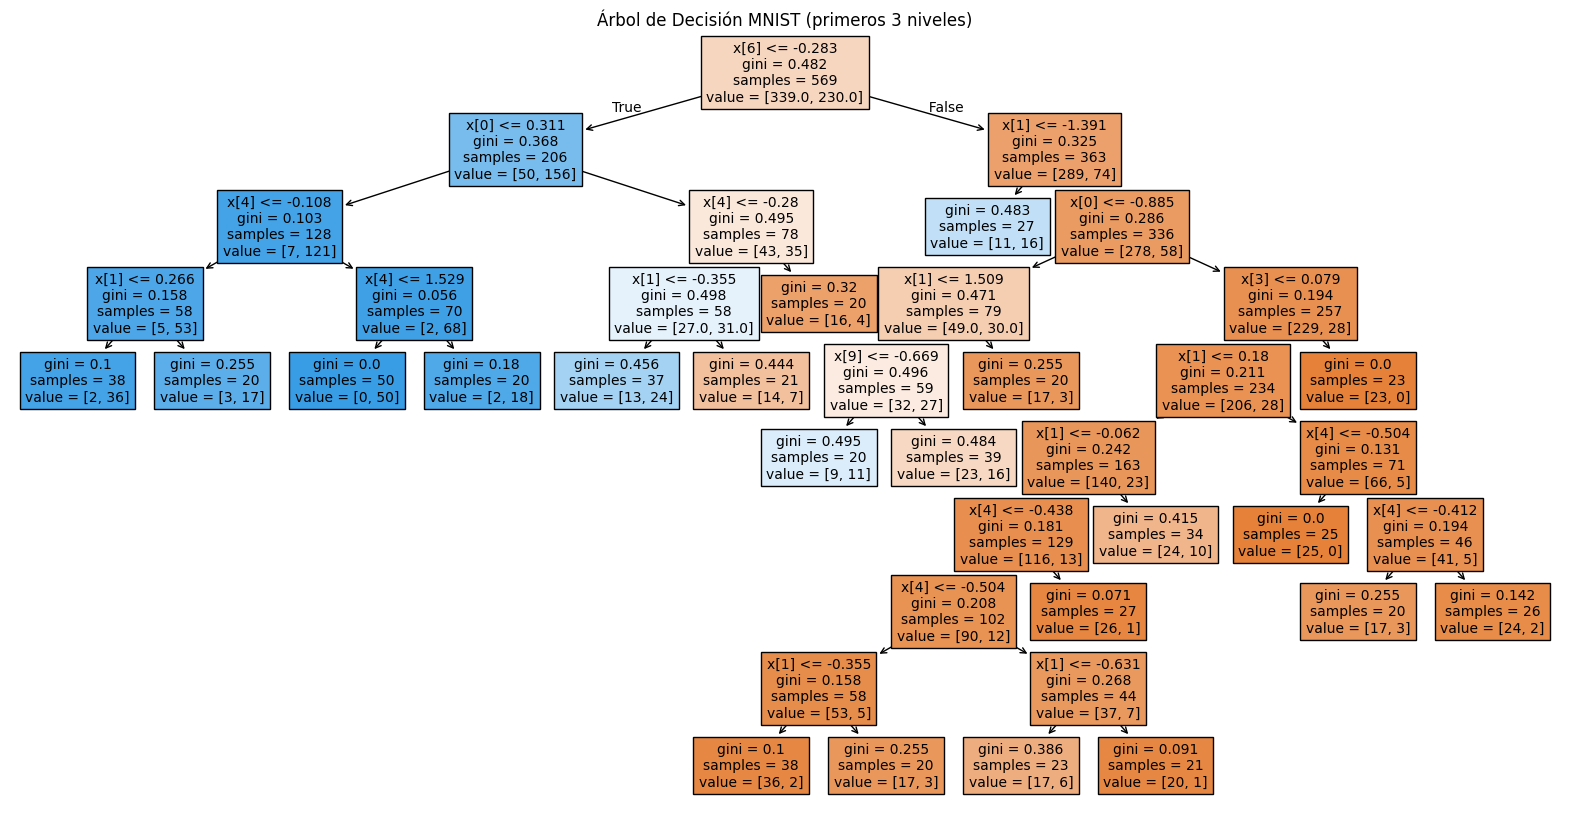

In [133]:
# Visualizar el árbol (solo primeros niveles por tamaño)
plt.figure(figsize=(20, 10))
plot_tree(tree_clf, 
          filled=True, 
          #feature_names=[f"pixel_{i}" for i in range(784)],
          #class_names=[str(i) for i in range(10)],
          #max_depth=3,  # Solo 2 niveles para que se vea
          fontsize=10)
plt.title("Árbol de Decisión MNIST (primeros 3 niveles)")
plt.show()

In [134]:

valores_C = [0.1, 1, 5, 10, 50, 100]
valores_gamma = [0.001, 0.01, 0.1, 1]
valores_degree = [2, 3, 4, 5]
valores_coef0 = [0, 0.5, 1, 2]

# Funcion que recibe como parametro el tipo de kernel para entrenar el modelo con distintos hiperparametros almacenados en listas
def mejor_eleccion(kernel):
    mejor_acc = 0
    mejor_config = None

    for C in valores_C:

        # LINEAR
        if kernel == 'linear':
            print(f"\nProbando LINEAR | C={C}")

            svm = SVC(kernel='linear', C=C, random_state=42)

            svm.fit(X_train, y_train)
            pred = svm.predict(X_test)
            acc = accuracy_score(y_test, pred)

            print(f"Accuracy: {acc:.4f}")

            if acc > mejor_acc:
                mejor_acc = acc
                mejor_config = ('linear', C)

        # RBF
        elif kernel == 'rbf':
            for gamma in valores_gamma:
                print(f"\nProbando RBF | C={C} | gamma={gamma}")

                svm = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)

                svm.fit(X_train, y_train)
                pred = svm.predict(X_test)
                acc = accuracy_score(y_test, pred)

                print(f"Accuracy: {acc:.4f}")

                if acc > mejor_acc:
                    mejor_acc = acc
                    mejor_config = ('rbf', C, gamma)

        # POLY 
        elif kernel == 'poly':
            for degree in valores_degree:
                for coef0 in valores_coef0:
                    print(f"\nProbando POLY | C={C} | degree={degree} | coef0={coef0}")

                    svm = SVC(kernel='poly', C=C, degree=degree, coef0=coef0, random_state=42)

                    svm.fit(X_train, y_train)
                    pred = svm.predict(X_test)
                    acc = accuracy_score(y_test, pred)

                    print(f"Accuracy: {acc:.4f}")

                    if acc > mejor_acc:
                        mejor_acc = acc
                        mejor_config = ('poly', C, degree, coef0)

    print(f"\nMejor Accuracy: {mejor_acc:.4f}")
    print(f"Mejor configuración: {mejor_config}")


Poly (C=0.1, degree=3, coef0=2) = 0.8252 
Rbf (C=1, gamma=0.1) = 0.8392
Lineal (C=0.1) = 0.7692

In [135]:
mejor_eleccion("rbf")


Probando RBF | C=0.1 | gamma=0.001
Accuracy: 0.5944

Probando RBF | C=0.1 | gamma=0.01
Accuracy: 0.7832

Probando RBF | C=0.1 | gamma=0.1
Accuracy: 0.7902

Probando RBF | C=0.1 | gamma=1
Accuracy: 0.7552

Probando RBF | C=1 | gamma=0.001
Accuracy: 0.7692

Probando RBF | C=1 | gamma=0.01
Accuracy: 0.7692

Probando RBF | C=1 | gamma=0.1
Accuracy: 0.8392

Probando RBF | C=1 | gamma=1
Accuracy: 0.7832

Probando RBF | C=5 | gamma=0.001
Accuracy: 0.7692

Probando RBF | C=5 | gamma=0.01
Accuracy: 0.7762

Probando RBF | C=5 | gamma=0.1
Accuracy: 0.7972

Probando RBF | C=5 | gamma=1
Accuracy: 0.7832

Probando RBF | C=10 | gamma=0.001
Accuracy: 0.7692

Probando RBF | C=10 | gamma=0.01
Accuracy: 0.8042

Probando RBF | C=10 | gamma=0.1
Accuracy: 0.7972

Probando RBF | C=10 | gamma=1
Accuracy: 0.7622

Probando RBF | C=50 | gamma=0.001
Accuracy: 0.7692

Probando RBF | C=50 | gamma=0.01
Accuracy: 0.8252

Probando RBF | C=50 | gamma=0.1
Accuracy: 0.7622

Probando RBF | C=50 | gamma=1
Accuracy: 0.7692